<a href="https://colab.research.google.com/github/geraintmelville/moneycraft_project/blob/main/MoneyCraft.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv('https://drive.google.com/uc?export=download&id=1TCAjS5KtRUrfBW_8tXB_jkTnJPJWNu3J') # Accounts df
df.dtypes

customer_id             int64
month                  object
acquisition_channel    object
region                 object
age_band               object
account_tier           object
monthly_fee             int64
joined_on_promo          bool
dtype: object

# Feature exploration and Cleaning

## Accounts df

In [3]:
df.shape

(179018, 8)

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.isna().sum()

customer_id            0
month                  0
acquisition_channel    0
region                 0
age_band               0
account_tier           0
monthly_fee            0
joined_on_promo        0
dtype: int64

### Customer ID

Customer ID has a datatype of int64 (which is desired), so there isn't a need to force it into such a form.

In [7]:
missing_customer_ids = df["customer_id"].isnull().sum()
print(f"Missing Customer IDs: {missing_customer_ids}")

Missing Customer IDs: 0


In [8]:
duplicated_customer_ids = df["customer_id"].duplicated().sum()
print(f"No. duplicated IDs : {duplicated_customer_ids}")

No. duplicated IDs : 163286


How many unique ids are there?

In [9]:
print(f"There are {df["customer_id"].nunique()} unique customers")

There are 15732 unique customers


Duplicate ids exist as customers pay on a monthly basis. To really check for duplicates per month for each customer, one subscription per customer per month

In [10]:
monthly_duplicates = df.duplicated(subset = ["customer_id", "month"]).sum()
print(f"Duplicate Customer IDs within the same month: {monthly_duplicates}")

Duplicate Customer IDs within the same month: 0


In [11]:
customer_id_validity = df[df["customer_id"] <= 0].sum().sum()
print(f"No. customer ids within an unvalid range: {customer_id_validity}")

No. customer ids within an unvalid range: 0


### Month

In [12]:
print(df.month.min())
print(df.month.max())
df["month"].value_counts()

2022-01
2024-12


month
2024-12    9775
2024-11    9501
2024-10    9147
2024-09    8865
2024-08    8604
2024-07    8319
2024-06    8083
2024-05    7794
2024-04    7480
2024-03    7196
2024-02    6974
2024-01    6689
2023-12    6372
2023-11    6081
2023-10    5843
2023-09    5569
2023-08    5350
2023-07    5104
2023-06    4862
2023-05    4588
2023-04    4354
2023-03    4055
2023-02    3773
2023-01    3543
2022-12    3260
2022-11    2980
2022-10    2701
2022-09    2443
2022-08    2165
2022-07    1862
2022-06    1591
2022-05    1345
2022-04    1086
2022-03     824
2022-02     560
2022-01     280
Name: count, dtype: int64

The months are within a feasible range, there are no abnormalities in the temporal data provided.

In [13]:
# Change month to date
df['month'] = pd.PeriodIndex(df['month'], freq='M')
df['month'].head()

0    2022-01
1    2022-01
2    2022-01
3    2022-01
4    2022-01
Name: month, dtype: period[M]

### Channel

How many unique channels are there?

In [14]:
print(f"There are {df["acquisition_channel"].nunique()} unique channels")

There are 6 unique channels


In [15]:
print(df["acquisition_channel"].value_counts())

acquisition_channel
Online             43906
Comparison Site    42794
Branch             33277
Referral           25160
Outbound           20298
Broker/IFA         13583
Name: count, dtype: int64


In [16]:
print(f"There are {df["acquisition_channel"].isna().sum()} nulls in the channel columns")

There are 0 nulls in the channel columns


### Region

In [17]:
print(f"There are {df['region'].nunique()} regions")

There are 6 regions


In [18]:
print(df["region"].value_counts())

region
London        42874
North         36890
South East    36613
Midlands      31012
Scotland      17852
Wales & NI    13777
Name: count, dtype: int64


Checking to see if there are any trailing spaces in the region names, they are also already in title form.

In [20]:
print(df["region"].unique().tolist())

['Scotland', 'London', 'South East', 'North', 'Midlands', 'Wales & NI']


### Age Bands

In [21]:
print(f"There are {df["age_band"].nunique()} age bands")

There are 6 age bands


In [22]:
print(df["age_band"].value_counts())

age_band
25-34    45265
35-44    44012
45-54    32397
55-64    22361
18-24    20988
65+      13995
Name: count, dtype: int64


The dataset is heavily comminated by 25-44 year olds

### Account tier

In [23]:
print(f"There are {df["account_tier"].nunique()} account tiers")

There are 4 account tiers


In [39]:
print(df["account_tier"].value_counts())

account_tier
Silver      57256
Gold        54411
Classic     35795
Platinum    31556
Name: count, dtype: int64


In [38]:
print(df["account_tier"].unique().tolist())

['Classic', 'Silver', 'Platinum', 'Gold']


### Monthly fee

In [25]:
print(f"There are {df["monthly_fee"].nunique()} fees")

There are 4 fees


In [33]:
df_fee_table = pd.pivot_table(data = df, values = "monthly_fee", index = "account_tier")
df_fee_table.sort_values("monthly_fee", ascending = True, inplace = True)
df_fee_table["monthly_fee"] = df_fee_table["monthly_fee"].round(2)

In [34]:
df_fee_table.head()

,monthly_fee
account_tier,
Classic,0.00
Silver,8.82
Gold,16.03
Platinum,25.75


The monthly fees are irregularly priced

### Joined on a promotional basis

In [35]:
print(df["joined_on_promo"].nunique())

2


In [36]:
print(df["joined_on_promo"].value_counts())

joined_on_promo
False    115271
True      63747
Name: count, dtype: int64


## Closure df

In [40]:
df_closure = pd.read_csv('https://drive.google.com/uc?export=download&id=13ITGgf4LkmWRlCjWS-xEU4l8Ih1SIOKq') # Reason df
df_closure.head()

,customer_id,close_month,reason_code
0,10755,2024-05,Switched provider
1,7582,2025-01,Unhappy with perks
2,2162,2024-11,Fees too high
3,3016,2023-02,Switched provider
4,564,2022-07,Poor service


In [95]:
df_closure.shape

(4023, 3)

In [58]:
df_closure.isna().sum()

customer_id    0
close_month    0
reason_code    0
dtype: int64

### Customer ID

In [41]:
df_closure.duplicated().sum()

np.int64(0)

### Customer ID

In [42]:
print(f"There are {df_closure["customer_id"].nunique()} unique customers")



There are 4023 unique customers


In [43]:
missing_customer_ids_closure = df_closure["customer_id"].isnull().sum()
print(f"Missing Customer IDs: {missing_customer_ids_closure}")

Missing Customer IDs: 0


In [44]:
customer_id_validity_closure = df_closure[df_closure["customer_id"] <= 0].sum().sum()
print(f"No. customer ids within an unvalid range: {customer_id_validity_closure}")

No. customer ids within an unvalid range: 0


### Close Month 

In [46]:
print(df_closure["close_month"].min())
print(df_closure["close_month"].max())

2022-02
2025-01


In [47]:
df_closure["close_month"].duplicated().sum()

np.int64(3987)

In [48]:
df_closure["close_month"].nunique()

36

In [53]:
monthly_duplicates_closure = df_closure.duplicated(subset = ["customer_id", "close_month"]).sum()
print(f"Duplicate Customer IDs within the same month: {monthly_duplicates_closure}")

Duplicate Customer IDs within the same month: 0


In [59]:
df_closure["close_month"].value_counts()

close_month
2025-01    211
2024-11    194
2024-07    187
2024-09    185
2024-06    184
2024-12    182
2024-10    177
2024-08    172
2024-05    164
2024-02    154
2024-04    145
2024-03    145
2023-11    143
2023-12    139
2023-10    135
2023-09    131
2024-01    128
2023-08    122
2023-07    112
2023-05    104
2023-06    104
2023-02    103
2023-04     86
2023-03     82
2022-11     71
2023-01     70
2022-12     67
2022-10     61
2022-07     50
2022-08     50
2022-09     47
2022-06     36
2022-05     32
2022-04     22
2022-03     19
2022-02      9
Name: count, dtype: int64

### Reason code

In [55]:
print(f"There are {df_closure["reason_code"].nunique()} unique reason codes")

There are 7 unique reason codes


In [56]:
df_closure["reason_code"].unique().tolist()

['Switched provider',
 'Unhappy with perks',
 'Fees too high',
 'Poor service',
 'Moved abroad',
 'Unknown',
 'Bereavement']

In [57]:
df_closure["reason_code"].value_counts()

reason_code
Fees too high         1268
Poor service           887
Unknown                635
Switched provider      623
Unhappy with perks     254
Moved abroad           210
Bereavement            146
Name: count, dtype: int64

## Marketing df

In [60]:
df_marketing = pd.read_csv('https://drive.google.com/uc?export=download&id=1m6tSVLT6IkExQ_xDnwBIUoFkgboDpyaL') # Marketing df
df_marketing.head(20)

,month,channel,spend_gbp
0,2022-01,Branch,7310.0
1,2022-01,Broker/IFA,4014.0
2,2022-01,Comparison Site,3162.0
3,2022-01,Online,3945.0
4,2022-01,Outbound,4899.0
5,2022-01,Referral,1872.0
6,2022-02,Branch,7882.0
7,2022-02,Broker/IFA,1989.0
8,2022-02,Comparison Site,3266.0
9,2022-02,Online,4231.0


### Month

In [ ]:
print(df_marketing["month"].min())
print(df_marketing["month"].max())

2022-01
2024-12


## Sort row

In [64]:
df = df.sort_values(['customer_id', 'month'])
df.head()

,customer_id,month,acquisition_channel,region,age_band,account_tier,monthly_fee,joined_on_promo
0,1,2022-01,Comparison Site,Scotland,25-34,Classic,0,False
280,1,2022-02,Comparison Site,Scotland,25-34,Classic,0,False
840,1,2022-03,Comparison Site,Scotland,25-34,Classic,0,False
1664,1,2022-04,Comparison Site,Scotland,25-34,Classic,0,False
2750,1,2022-05,Comparison Site,Scotland,25-34,Classic,0,False


## Group by customer_id

In [65]:
# This will be the customer tenure
df.groupby('customer_id')['month'].count().head()

customer_id
1     6
2    36
3    36
4    36
5    10
Name: month, dtype: int64

### Save and build the columns

In [66]:
from typing import AsyncGenerator
grouped = df.groupby('customer_id')

signup_month = grouped['month'].min()   # First month
last_active = grouped['month'].max()   # last month
tenure_months = grouped['month'].count()    # total tenure
channel = grouped['acquisition_channel'].first()
age_band = grouped['age_band'].first()
region = grouped['region'].first()
first_plan = grouped['account_tier'].first()
last_plan = grouped['account_tier'].last()
total_revenue = grouped['monthly_fee'].sum()
max_paid = grouped['monthly_fee'].max()
# ever_paid = grouped['monthly_fee' > 0]


### Single Customer view
Single row per customer

Single Customer view - Cols needed
Signup_month - Month joined
Last_active - max(df[‘month’].groupby(customer_id))
Tenure (_months)
Channel
age_band
first_plan
last_plan
region
Age_band
Total_revenue
Max_paid
Ever_paid (max_paid>0)
Churned (last_active < final_month)


In [67]:
scv = pd.DataFrame({
    'signup_month': signup_month,
   'last_active': last_active,
    'tenure_months': tenure_months,
    'channel': channel,
    'age_band': age_band,
    'region': region,
    'first_plan': first_plan,
    'last_plan': last_plan,
    'total_revenue': total_revenue,
    'max_paid': max_paid
})

scv['ever_paid'] = max_paid > 0
scv.head()

,signup_month,last_active,tenure_months,channel,age_band,region,first_plan,last_plan,total_revenue,max_paid,ever_paid
customer_id,,,,,,,,,,,
1,2022-01,2022-06,6,Comparison Site,25-34,Scotland,Classic,Classic,0,0,False
2,2022-01,2024-12,36,Online,55-64,London,Silver,Platinum,595,28,True
3,2022-01,2024-12,36,Branch,25-34,South East,Platinum,Platinum,848,28,True
4,2022-01,2024-12,36,Referral,25-34,London,Silver,Silver,330,11,True
5,2022-01,2022-10,10,Comparison Site,35-44,South East,Silver,Classic,33,11,True


In [68]:
from typing_extensions import final
# Add churned flag
final_month = df['month'].max()   # Last month in data
scv['churned'] = scv['last_active'] < final_month
scv.head()
# scv[['signup_month', 'last_active', 'tenure_months', 'churned']].head()

,signup_month,last_active,tenure_months,channel,age_band,region,first_plan,last_plan,total_revenue,max_paid,ever_paid,churned
customer_id,,,,,,,,,,,,
1,2022-01,2022-06,6,Comparison Site,25-34,Scotland,Classic,Classic,0,0,False,True
2,2022-01,2024-12,36,Online,55-64,London,Silver,Platinum,595,28,True,False
3,2022-01,2024-12,36,Branch,25-34,South East,Platinum,Platinum,848,28,True,False
4,2022-01,2024-12,36,Referral,25-34,London,Silver,Silver,330,11,True,False
5,2022-01,2022-10,10,Comparison Site,35-44,South East,Silver,Classic,33,11,True,True


***CALCULATE: the churn rate***

In [69]:
scv['churned'].mean().round(2)

np.float64(0.38)

*Don't forget we need to merge the tables*

In [82]:
# Merging tables - main table with closure data
df_merged = pd.merge(scv, df_closure, on='customer_id', how='left')
df_merged.head()

,customer_id,signup_month,last_active,tenure_months,channel,age_band,region,first_plan,last_plan,total_revenue,max_paid,ever_paid,churned,close_month,reason_code
0,1,2022-01,2022-06,6,Comparison Site,25-34,Scotland,Classic,Classic,0,0,False,True,2022-07,Switched provider
1,2,2022-01,2024-12,36,Online,55-64,London,Silver,Platinum,595,28,True,False,NaN,NaN
2,3,2022-01,2024-12,36,Branch,25-34,South East,Platinum,Platinum,848,28,True,False,NaN,NaN
3,4,2022-01,2024-12,36,Referral,25-34,London,Silver,Silver,330,11,True,False,NaN,NaN
4,5,2022-01,2022-10,10,Comparison Site,35-44,South East,Silver,Classic,33,11,True,True,2022-11,Bereavement


In [83]:
df_merged[(df_merged["churned"] == True) & (df_merged["reason_code"].isnull())]

,customer_id,signup_month,last_active,tenure_months,channel,age_band,region,first_plan,last_plan,total_revenue,max_paid,ever_paid,churned,close_month,reason_code
6,7,2022-01,2023-05,17,Outbound,45-54,Scotland,Silver,Silver,187,11,True,True,NaN,NaN
13,14,2022-01,2024-06,30,Online,45-54,Midlands,Silver,Classic,110,11,True,True,NaN,NaN
27,28,2022-01,2022-07,7,Comparison Site,45-54,London,Silver,Classic,0,0,False,True,NaN,NaN
37,38,2022-01,2022-05,5,Outbound,35-44,Scotland,Classic,Classic,0,0,False,True,NaN,NaN
39,40,2022-01,2022-12,12,Referral,25-34,Midlands,Silver,Silver,66,11,True,True,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14947,14948,2024-11,2024-11,1,Outbound,35-44,South East,Classic,Classic,0,0,False,True,NaN,NaN
14950,14951,2024-11,2024-11,1,Referral,55-64,London,Classic,Classic,0,0,False,True,NaN,NaN
14993,14994,2024-11,2024-11,1,Comparison Site,55-64,South East,Classic,Classic,0,0,False,True,NaN,NaN
14997,14998,2024-11,2024-11,1,Online,45-54,London,Classic,Classic,0,0,False,True,NaN,NaN


In [84]:
df_merged.loc[(df_merged["churned"] == True) & (df_merged["reason_code"].isnull()), "reason_code"] = "Unknown"
df_merged.loc[(df_merged["churned"] == False) & (df_merged["reason_code"].isnull()), "reason_code"] = "N/A"

In [98]:
df_merged["reason_code"].value_counts()

reason_code
N/A                   9564
Unknown               2780
Fees too high         1268
Poor service           887
Switched provider      623
Unhappy with perks     254
Moved abroad           210
Bereavement            146
Name: count, dtype: int64

In [88]:
df_merged["last_active"].isna().sum()

np.int64(0)

In [89]:
df_merged["close_month"].isna().sum()

np.int64(11709)

In [94]:
df_merged[(df_merged["last_active"].isnull() == False) & (df_merged["close_month"].isnull() == False)].count()

customer_id      4023
signup_month     4023
last_active      4023
tenure_months    4023
channel          4023
age_band         4023
region           4023
first_plan       4023
last_plan        4023
total_revenue    4023
max_paid         4023
ever_paid        4023
churned          4023
close_month      4023
reason_code      4023
dtype: int64

In [99]:
df_merged.drop(columns = ["close_month"], inplace = True)

df_merged.head()

,customer_id,signup_month,last_active,tenure_months,channel,age_band,region,first_plan,last_plan,total_revenue,max_paid,ever_paid,churned,reason_code
0,1,2022-01,2022-06,6,Comparison Site,25-34,Scotland,Classic,Classic,0,0,False,True,Switched provider
1,2,2022-01,2024-12,36,Online,55-64,London,Silver,Platinum,595,28,True,False,N/A
2,3,2022-01,2024-12,36,Branch,25-34,South East,Platinum,Platinum,848,28,True,False,N/A
3,4,2022-01,2024-12,36,Referral,25-34,London,Silver,Silver,330,11,True,False,N/A
4,5,2022-01,2022-10,10,Comparison Site,35-44,South East,Silver,Classic,33,11,True,True,Bereavement


***Find out when and why most customers left***
*Then look into changing NaN to 'No reason given'*
*Create a rentention curve*

**Channel bar chart**
**Bool and category** Yes or No

In [ ]:
# Retention curve
max_t = int(scv['tenure_months'].max())
# max_time = max_t + 1

# For each mont
retention = [(scv['tenure_months']> t).mean() for t in range(max_t)]
retention[:5]

[np.float64(1.0),
 np.float64(0.9057971014492754),
 np.float64(0.8263412153572337),
 np.float64(0.7631578947368421),
 np.float64(0.7072209509280447)]

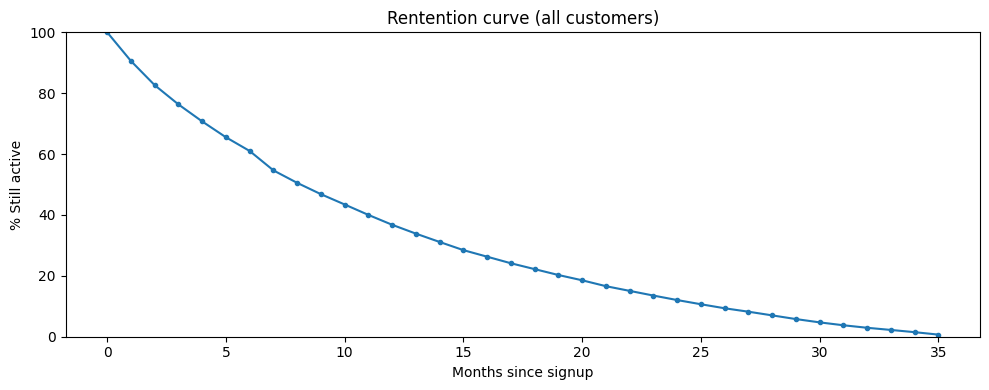

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(range(max_t), [r * 100 for r in retention], marker='.')
plt.title('Rentention curve (all customers)')
plt.xlabel('Months since signup')
plt.ylabel('% Still active')
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

Cohort based on channel and subscriptions

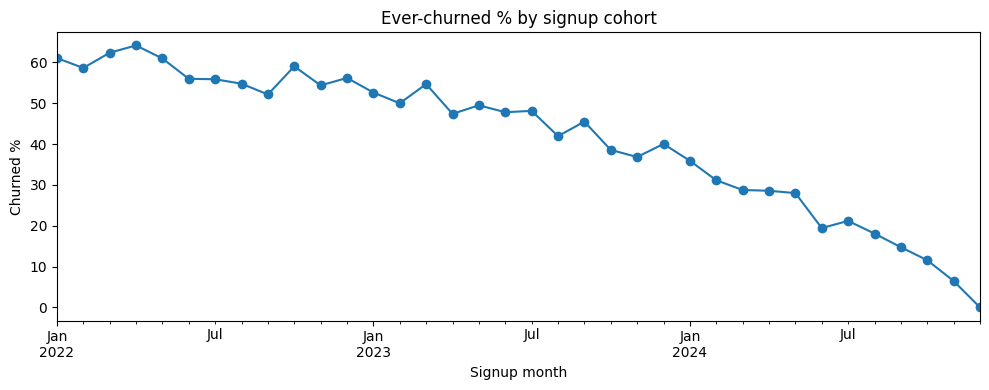

In [ ]:
# Cohorts
cohort_churn = scv.groupby('signup_month')['churned'].mean() * 100

plt.figure(figsize=(10, 4))
cohort_churn.plot(marker='o')
plt.title('Ever-churned % by signup cohort')
plt.xlabel('Signup month')
plt.ylabel('Churned %')
plt.tight_layout()
plt.show()

**LIFETIME VALUE (LTV)**

In [ ]:
within_tier = ()

In [ ]:
df_merged.to_csv("merged_closure.csv", index=True)

In [ ]:
df_merged.head()

,customer_id,signup_month,last_active,tenure_months,channel,age_band,region,first_plan,last_plan,total_revenue,max_paid,ever_paid,churned,close_month,reason_code
0,1,2022-01,2022-06,6,Comparison Site,25-34,Scotland,Classic,Classic,0,0,False,True,2022-07,Switched provider
1,2,2022-01,2024-12,36,Online,55-64,London,Silver,Platinum,595,28,True,False,NaN,NaN
2,3,2022-01,2024-12,36,Branch,25-34,South East,Platinum,Platinum,848,28,True,False,NaN,NaN
3,4,2022-01,2024-12,36,Referral,25-34,London,Silver,Silver,330,11,True,False,NaN,NaN
4,5,2022-01,2022-10,10,Comparison Site,35-44,South East,Silver,Classic,33,11,True,True,2022-11,Bereavement


In [ ]:
df_merged.isna().sum()

,0
customer_id,0
signup_month,0
last_active,0
tenure_months,0
channel,0
age_band,0
region,0
first_plan,0
last_plan,0
total_revenue,0


In [ ]:
df_merged_chruned = df_merged.dropna()

# Graphs - EDA

In [100]:
df_merged.head()

,customer_id,signup_month,last_active,tenure_months,channel,age_band,region,first_plan,last_plan,total_revenue,max_paid,ever_paid,churned,reason_code
0,1,2022-01,2022-06,6,Comparison Site,25-34,Scotland,Classic,Classic,0,0,False,True,Switched provider
1,2,2022-01,2024-12,36,Online,55-64,London,Silver,Platinum,595,28,True,False,N/A
2,3,2022-01,2024-12,36,Branch,25-34,South East,Platinum,Platinum,848,28,True,False,N/A
3,4,2022-01,2024-12,36,Referral,25-34,London,Silver,Silver,330,11,True,False,N/A
4,5,2022-01,2022-10,10,Comparison Site,35-44,South East,Silver,Classic,33,11,True,True,Bereavement


* Plot pie chart of account tiers
* avg tenure per account tier per region (grouped bar chart)
* revenue per  age band ( most revenue driven demographic)
* churn rate per quarter


In [101]:
import matplotlib.pyplot as plt
import seaborn as sns

In [120]:
def autopct_format(values):
        def my_format(pct):
            total = sum(values)
            val = int(round(pct*total/100.0))
            return '{:.1f}%\n({v:d})'.format(pct, v=val)
        return my_format

In [126]:
colour_palette = ["#6C2BD9", # Violet
                  "#8B5CF6", # Electric Violet
                  "#211A3B", # Ink
                  "#2DD4BF", # Mint
                  "#E9E1FA", # Lilac Mist
                  "#F6F4FC"] # Cloud

region
London        3778
South East    3200
North         3197
Midlands      2791
Scotland      1563
Wales & NI    1203
Name: count, dtype: int64


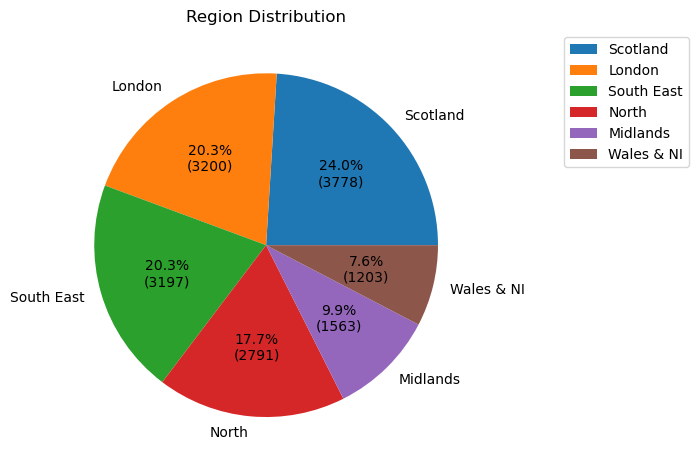

In [129]:
labels = df_merged["region"].unique().tolist()
sizes = df_merged["region"].value_counts()

print(sizes)


plt.pie(sizes, labels = labels, autopct=autopct_format(sizes))
plt.title("Region Distribution", loc= "center")
plt.legend(loc = "upper right", bbox_to_anchor=(1, 0, 0.5, 1))
plt.tight_layout()
plt.show()